# Run, test et évaluation des modèles (+ clustering)

## 1. Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
import joblib



from src.model.kmeans import *
from src.model.cluster_analyzing import *
from src.model.model_evaluation import *
from src.features.features_groups import *


## 2. Chargement des données

In [2]:
FINAL_DATASET_JSON_PATH = Path("../data/final/final_dataset.json")
FINAL_DATASET_RAW_JSON_PATH = Path("../data/final_scaled/X_raw_clustering.parquet")
FINAL_DATASET_TRANSFORMED_JSON_PATH = Path("../data/final_scaled/X_transformed.parquet")
FINAL_DATASET_SCALED_JSON_PATH = Path("../data/final_scaled/X_scaled.parquet")
MODEL_OUTPUTS_PATH = Path("../data/final/model_outputs/comparison_table.csv")
MODEL_OUTPUTS_RESULTS_PATH = Path("../data/final/model_outputs/all_results.pkl")
MODEL_OUTPUTS_FILTERED_PATH = Path("../data/final/model_outputs/filter/comparison_table.csv")
MODEL_OUTPUTS_FILTERED_RESULTS_PATH = Path("../data/final/model_outputs/filter/all_results.pkl")


final_dataset = pd.read_json(FINAL_DATASET_JSON_PATH)
X_scaled = pd.read_parquet(FINAL_DATASET_SCALED_JSON_PATH)

print(final_dataset.shape)
print(X_scaled.shape)

(298, 34)
(298, 15)


## 3. Vérification d'alignement

In [3]:
assert len(final_dataset) == len(X_scaled), "Mismatch entre final_dataset et X_scaled"

missing_in_scaled = [c for c in SELECTED_FEATURE_COLS_FINAL if c not in X_scaled.columns]
extra_in_scaled = [c for c in X_scaled.columns if c not in SELECTED_FEATURE_COLS_FINAL]

print("Missing in X_scaled:", missing_in_scaled)
print("Extra in X_scaled:", extra_in_scaled)

assert not missing_in_scaled, "Certaines features finales sont absentes de X_scaled"
assert not extra_in_scaled, "X_scaled contient des colonnes inattendues"

X_scaled = X_scaled[SELECTED_FEATURE_COLS_FINAL]

X_scaled.head()

Missing in X_scaled: []
Extra in X_scaled: []


,mean_ply_count,opening_diversity,draw_ratio,score_when_winstreak,score_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_interval,cv_games_per_day,cv_games_per_week,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,weekday_bias,color_bias
0,-1.634128,-1.487510,0.701653,0.386847,-0.790694,0.082496,-0.137330,0.503156,0.281429,0.238232,0.442384,1.066812,0.633159,-0.383378,1.056363
1,-1.083248,-1.055074,0.200179,-2.365164,-1.503167,-0.022063,-0.076599,-0.193409,0.863668,-0.031632,0.159186,-0.038154,0.644538,-0.714865,0.494206
2,1.258703,0.591611,0.497257,-0.432019,0.946763,0.340110,-0.777550,-0.450901,0.598068,0.871385,0.792627,-0.918362,-0.845833,-1.227418,-1.329976
3,-1.222493,0.206968,-0.597136,-0.141192,-0.028219,0.193068,-0.503066,0.092778,0.134010,-0.468019,0.724307,0.333064,0.247324,-0.026253,0.830394
4,0.508411,-0.132326,-0.035811,0.847621,-0.732705,-0.354068,-0.661163,0.485067,0.023523,0.954004,-0.072829,-0.355550,0.175098,0.054733,-0.408264


## 4. Affichage des groupes

In [4]:
FEATURE_GROUPS_UPDATED

{'style': ['mean_ply_count', 'opening_diversity'],
 'endgame': ['draw_ratio'],
 'streaks': ['score_when_winstreak',
  'score_when_losestreak',
  'delay_ratio_when_winstreak',
  'delay_ratio_when_losestreak'],
 'global_rhythm': ['cv_games_per_day',
  'cv_games_per_week',
  'cv_games_interval'],
 'sessions': ['entropy_sessions_interval',
  'mean_games_per_session',
  'cv_games_per_session'],
 'context': ['weekday_bias', 'color_bias']}

## 5. Définir les feature sets à tester

### 5.1 Set 1 : FEATURE_SET_ALL
Les 15 features

In [5]:
FEATURE_SET_ALL = SELECTED_FEATURE_COLS_FINAL
FEATURE_SET_ALL

['mean_ply_count',
 'opening_diversity',
 'draw_ratio',
 'score_when_winstreak',
 'score_when_losestreak',
 'delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_interval',
 'cv_games_per_day',
 'cv_games_per_week',
 'entropy_sessions_interval',
 'mean_games_per_session',
 'cv_games_per_session',
 'weekday_bias',
 'color_bias']

### 5.2 Set 2 : FEATURE_SET_BALANCED
Une sélection homogène des features par sous-catégorie. 1 à 2 features par catégorie.


In [6]:
FEATURE_SET_BALANCED = [
    "mean_ply_count",
    "opening_diversity",
    "draw_ratio",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "cv_games_interval",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "weekday_bias",
    "color_bias",
]
FEATURE_SET_BALANCED

['mean_ply_count',
 'opening_diversity',
 'draw_ratio',
 'delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_per_day',
 'cv_games_interval',
 'entropy_sessions_interval',
 'mean_games_per_session',
 'weekday_bias',
 'color_bias']

### 5.3 Set 3 : FEATURE_SET_TEMPORAL
Composantes temporelles


In [7]:
FEATURE_SET_TEMPORAL = [
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
    "entropy_sessions_interval"
]
FEATURE_SET_TEMPORAL

['delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_per_day',
 'cv_games_per_week',
 'cv_games_interval',
 'entropy_sessions_interval']

### 5.4 Set 4 : FEATURE_SET_NON_TEMPORAL
Composantes non temporelles


In [8]:
FEATURE_SET_NON_TEMPORAL = [
    "mean_ply_count",
    "opening_diversity",
    "draw_ratio",
    "mean_games_per_session",
    "cv_games_per_session",
    "weekday_bias",
    "color_bias",
]
FEATURE_SET_NON_TEMPORAL

['mean_ply_count',
 'opening_diversity',
 'draw_ratio',
 'mean_games_per_session',
 'cv_games_per_session',
 'weekday_bias',
 'color_bias']

### 5.5 Set 5 : FEATURE_SET_10
Les 10 features les plus pertinentes en termes d'interprétation selon moi


In [9]:
FEATURE_SET_10 = [
    "opening_diversity",
    "draw_ratio",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
]
FEATURE_SET_10

['opening_diversity',
 'draw_ratio',
 'delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_per_day',
 'cv_games_per_week',
 'cv_games_interval',
 'entropy_sessions_interval',
 'mean_games_per_session',
 'cv_games_per_session']

### 5.6 Set 6 : FEATURE_SET_6
Les 6 features les plus pertinentes en termes d'interprétation selon moi


In [10]:
FEATURE_SET_6 = [
    "opening_diversity",
    "draw_ratio",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "entropy_sessions_interval",
]
FEATURE_SET_6

['opening_diversity',
 'draw_ratio',
 'delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_per_day',
 'entropy_sessions_interval']

### 5.7 Bilan

In [11]:
FEATURE_SETS = {
    "ALL": FEATURE_SET_ALL,
    "BALANCED": FEATURE_SET_BALANCED,
    "TEMPORAL": FEATURE_SET_TEMPORAL,
    "NON_TEMPORAL": FEATURE_SET_NON_TEMPORAL,
    "TOP10": FEATURE_SET_10,
    "TOP6": FEATURE_SET_6,
}

FEATURE_SETS.keys()

dict_keys(['ALL', 'BALANCED', 'TEMPORAL', 'NON_TEMPORAL', 'TOP10', 'TOP6'])

### 5.8 Test sur des paires de catégories de features

Cette approche combine petit set + interprétabilité métier

In [12]:
# FEATURE_SET_STYLE_ENDGAME = [
#     "mean_ply_count",
#     "opening_diversity",
#     "draw_ratio",
# ]

# FEATURE_SET_STYLE_STREAKS = [
#     "mean_ply_count",
#     "opening_diversity",
#     "score_when_winstreak",
#     "score_when_losestreak",
#     "delay_ratio_when_winstreak",
#     "delay_ratio_when_losestreak",
# ]

# FEATURE_SET_STYLE_GLOBAL_RHYTHM = [
#     "mean_ply_count",
#     "opening_diversity",
#     "cv_games_per_day",
#     "cv_games_per_week",
#     "cv_games_interval",
# ]

# FEATURE_SET_STYLE_SESSIONS = [
#     "mean_ply_count",
#     "opening_diversity",
#     "entropy_sessions_interval",
#     "mean_games_per_session",
#     "cv_games_per_session",
# ]

# FEATURE_SET_STYLE_CONTEXT = [
#     "mean_ply_count",
#     "opening_diversity",
#     "weekday_bias",
#     "color_bias",
# ]

# FEATURE_SET_ENDGAME_STREAKS = [
#     "draw_ratio",
#     "score_when_winstreak",
#     "score_when_losestreak",
#     "delay_ratio_when_winstreak",
#     "delay_ratio_when_losestreak",
# ]

# FEATURE_SET_ENDGAME_GLOBAL_RHYTHM = [
#     "draw_ratio",
#     "cv_games_per_day",
#     "cv_games_per_week",
#     "cv_games_interval",
# ]

# FEATURE_SET_ENDGAME_SESSIONS = [
#     "draw_ratio",
#     "entropy_sessions_interval",
#     "mean_games_per_session",
#     "cv_games_per_session",
# ]

# FEATURE_SET_ENDGAME_CONTEXT = [
#     "draw_ratio",
#     "weekday_bias",
#     "color_bias",
# ]

# FEATURE_SET_STREAKS_GLOBAL_RHYTHM = [
#     "score_when_winstreak",
#     "score_when_losestreak",
#     "delay_ratio_when_winstreak",
#     "delay_ratio_when_losestreak",
#     "cv_games_per_day",
#     "cv_games_per_week",
#     "cv_games_interval",
# ]

# FEATURE_SET_STREAKS_SESSIONS = [
#     "score_when_winstreak",
#     "score_when_losestreak",
#     "delay_ratio_when_winstreak",
#     "delay_ratio_when_losestreak",
#     "entropy_sessions_interval",
#     "mean_games_per_session",
#     "cv_games_per_session",
# ]

# FEATURE_SET_STREAKS_CONTEXT = [
#     "score_when_winstreak",
#     "score_when_losestreak",
#     "delay_ratio_when_winstreak",
#     "delay_ratio_when_losestreak",
#     "weekday_bias",
#     "color_bias",
# ]

# FEATURE_SET_GLOBAL_RHYTHM_SESSIONS = [
#     "cv_games_per_day",
#     "cv_games_per_week",
#     "cv_games_interval",
#     "entropy_sessions_interval",
#     "mean_games_per_session",
#     "cv_games_per_session",
# ]

# FEATURE_SET_GLOBAL_RHYTHM_CONTEXT = [
#     "cv_games_per_day",
#     "cv_games_per_week",
#     "cv_games_interval",
#     "weekday_bias",
#     "color_bias",
# ]

# FEATURE_SET_SESSIONS_CONTEXT = [
#     "entropy_sessions_interval",
#     "mean_games_per_session",
#     "cv_games_per_session",
#     "weekday_bias",
#     "color_bias",
# ]


FEATURE_SET_STYLE_ENDGAME = [
    "mean_ply_count",
    "opening_diversity",
    "draw_ratio",
]

FEATURE_SET_STYLE_STREAKS = [
    "mean_ply_count",
    "opening_diversity",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
]

FEATURE_SET_STYLE_GLOBAL_RHYTHM = [
    "mean_ply_count",
    "opening_diversity",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
]

FEATURE_SET_STYLE_SESSIONS = [
    "mean_ply_count",
    "opening_diversity",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
]

FEATURE_SET_STYLE_CONTEXT = [
    "mean_ply_count",
    "opening_diversity",
    "weekday_bias",
    "color_bias",
]

FEATURE_SET_ENDGAME_STREAKS = [
    "draw_ratio",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
]

FEATURE_SET_ENDGAME_GLOBAL_RHYTHM = [
    "draw_ratio",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
]

FEATURE_SET_ENDGAME_SESSIONS = [
    "draw_ratio",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
]

FEATURE_SET_ENDGAME_CONTEXT = [
    "draw_ratio",
    "weekday_bias",
    "color_bias",
]

FEATURE_SET_STREAKS_GLOBAL_RHYTHM = [
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
]

FEATURE_SET_STREAKS_SESSIONS = [
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
]

FEATURE_SET_STREAKS_CONTEXT = [
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "weekday_bias",
    "color_bias",
]

FEATURE_SET_GLOBAL_RHYTHM_SESSIONS = [
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
]

FEATURE_SET_GLOBAL_RHYTHM_CONTEXT = [
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
    "weekday_bias",
    "color_bias",
]

FEATURE_SET_SESSIONS_CONTEXT = [
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
    "weekday_bias",
    "color_bias",
]


In [4]:
from itertools import combinations

FEATURE_POOL = [
    "mean_ply_count",
    "opening_diversity",
    "draw_ratio",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak",
    "cv_games_per_day",
    "cv_games_per_week",
    "cv_games_interval",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session",
    #"weekday_bias",
    "color_bias",
]

FEATURE_SETS = {}

for r in [2, 3, 4, 5]:
    for combo in combinations(FEATURE_POOL, r):
        set_name = f"COMBO_{r}_" + "__".join(combo)
        FEATURE_SETS[set_name] = list(combo)

print(f"Nombre total de sets générés : {len(FEATURE_SETS)}")


Nombre total de sets générés : 1573


In [ ]:
# FEATURE_SETS = {

#     "ALL": FEATURE_SET_ALL,
    # "BALANCED": FEATURE_SET_BALANCED,
    # "TEMPORAL": FEATURE_SET_TEMPORAL,
    # "NON_TEMPORAL": FEATURE_SET_NON_TEMPORAL,
    # "TOP10": FEATURE_SET_10,
    # "TOP6": FEATURE_SET_6,

    # "STYLE_ENDGAME": FEATURE_SET_STYLE_ENDGAME,
    # "STYLE_STREAKS": FEATURE_SET_STYLE_STREAKS,
    # "STYLE_GLOBAL_RHYTHM": FEATURE_SET_STYLE_GLOBAL_RHYTHM,
    # "STYLE_SESSIONS": FEATURE_SET_STYLE_SESSIONS,
    # "STYLE_CONTEXT": FEATURE_SET_STYLE_CONTEXT,

    # "ENDGAME_STREAKS": FEATURE_SET_ENDGAME_STREAKS,
    # "ENDGAME_GLOBAL_RHYTHM": FEATURE_SET_ENDGAME_GLOBAL_RHYTHM,
    # "ENDGAME_SESSIONS": FEATURE_SET_ENDGAME_SESSIONS,
    # "ENDGAME_CONTEXT": FEATURE_SET_ENDGAME_CONTEXT,

    # "STREAKS_GLOBAL_RHYTHM": FEATURE_SET_STREAKS_GLOBAL_RHYTHM,
    # "STREAKS_SESSIONS": FEATURE_SET_STREAKS_SESSIONS,
    # "STREAKS_CONTEXT": FEATURE_SET_STREAKS_CONTEXT,

    # "GLOBAL_RHYTHM_SESSIONS": FEATURE_SET_GLOBAL_RHYTHM_SESSIONS,
    # "GLOBAL_RHYTHM_CONTEXT": FEATURE_SET_GLOBAL_RHYTHM_CONTEXT,

    # "SESSIONS_CONTEXT": FEATURE_SET_SESSIONS_CONTEXT,
# }

## 6. Hyperparamètres

In [5]:
K_VALUES = [2, 3, 4, 5]
N_SEEDS = 20

## 7. Run global

Le code suivant éxécute pour chaque feature set, et pour chaque k (2,3,4,5,6), 20 runs (seeds). Ensuite, il conserve pour chaque paire feature set et chaque k, il est gardé la meilleur seed sur base de la fonction de score suivante : 0.7 std + 0.3 silhouette.
- std : "elo_slope_per_game_std_between_clusters_weighted", soit la dispersion de l'elo slope par cluster, pondérée selon la taille du cluster. Le plus important est que le modèle maximise la séparation des profils de progression, d'où le poids important de cette métrique

In [31]:
ALL_RESULTS = evaluate_all_feature_sets(
    X_scaled=X_scaled,
    final_dataset=final_dataset,
    feature_sets=FEATURE_SETS,
    performance_features=PERFORMANCE_FEATURES,
    progression_labels=PROGRESSION_LABELS,
    k_values=K_VALUES, 
    n_seeds=N_SEEDS,
)



# 8. Table globale de comparaison

Il est donc affiché pour chaque feature set et pour chaque k plusieurs métriques :
- silouhette (doit tendre vers 1)
- inertia (doit être minimale)
- imbalance_ratio (= min_cluster_size/max_cluster_size, doit tendre vers 1)
- elo_slope_per_game_range (doit être maximal)
- elo_slope_per_game_std_between_clusters (doit être maximal)

In [33]:
comparison_df = build_comparison_table(ALL_RESULTS)
#comparison_df

## 9. Sauvegarde des données

In [34]:
comparison_df.to_csv(MODEL_OUTPUTS_PATH, index=False)

joblib.dump(ALL_RESULTS, MODEL_OUTPUTS_RESULTS_PATH)

['..\\data\\final\\model_outputs\\all_results.pkl']

## 10. Premier tri rapide

In [ ]:
#comparison_df = pd.read_csv(MODEL_OUTPUTS_PATH)
#ALL_RESULTS = joblib.load(MODEL_OUTPUTS_RESULTS_PATH)


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

filtered_df = comparison_df[
    (comparison_df["silhouette"] > 0.1)
    & (comparison_df["elo_slope_per_game_std_between_clusters_weighted"] > 0.1)
]

comparison_df.sort_values(
    by=[
        "elo_slope_per_game_std_between_clusters_weighted",
        "silhouette",
        
    ],
    ascending=[False, False]
)

#print("cc")

comparison_df_filtered = comparison_df[
    (comparison_df["imbalance_ratio"] >= 0.2) &
    (comparison_df["min_cluster_size"] >= 20) &
    (comparison_df["silhouette"] >= 0.1)
].copy()

comparison_df_filtered2 = comparison_df[
    (comparison_df["imbalance_ratio"] >= 0.2) &
    (comparison_df["min_cluster_size"] >= 20) &
    (comparison_df["silhouette"] >= 0.15) &   # léger seuil
    (comparison_df["k"] >= 3) &               # important
    (comparison_df["elo_slope_per_game_std_between_clusters_weighted"] >= 0.1)
].copy()

comparison_df_filtered2 = comparison_df_filtered2.sort_values(
    by=[
        "elo_slope_per_game_std_between_clusters_weighted",
        "silhouette",
        "elo_slope_per_game_std_within_clusters_weighted",
    ],
    ascending=[False, False, False]
)


comparison_df_filtered2.to_csv(MODEL_OUTPUTS_PATH, index=False)


comparison_df_filtered2.head(len(comparison_df_filtered2))

,feature_set_name,n_features,k,best_seed,silhouette,inertia,min_cluster_size,max_cluster_size,imbalance_ratio,elo_slope_per_game_range,elo_slope_per_game_std_between_clusters,elo_slope_per_game_std_between_clusters_weighted,elo_slope_per_game_std_within_clusters_weighted
4327,COMBO_5_mean_ply_count__delay_ratio_when_loses...,5,5,14,0.183664,421.953432,51,78,0.653846,0.346945,0.119862,0.112294,0.356816
4671,COMBO_5_mean_ply_count__draw_ratio__cv_games_p...,5,5,12,0.170983,459.845480,28,82,0.341463,0.316362,0.116517,0.110136,0.357811
2287,COMBO_4_mean_ply_count__delay_ratio_when_winst...,4,5,10,0.191400,343.472167,27,70,0.385714,0.283862,0.106374,0.109109,0.356787
915,COMBO_3_mean_ply_count__entropy_sessions_inter...,3,5,14,0.246181,188.878590,28,86,0.325581,0.276799,0.097656,0.108338,0.355340
3735,COMBO_5_draw_ratio__cv_games_per_week__cv_game...,5,5,13,0.182652,461.951006,22,84,0.261905,0.296023,0.114769,0.107447,0.355763
2035,COMBO_4_mean_ply_count__cv_games_per_day__cv_g...,4,5,18,0.244178,293.333257,32,100,0.320000,0.352305,0.121177,0.105965,0.360211
2339,COMBO_4_mean_ply_count__draw_ratio__cv_games_p...,4,5,19,0.202415,301.201426,43,94,0.457447,0.363422,0.119664,0.105423,0.358301
2011,COMBO_4_mean_ply_count__cv_games_per_day__cv_g...,4,5,11,0.196941,343.431544,41,91,0.450549,0.357611,0.117400,0.104904,0.360880
4814,COMBO_5_mean_ply_count__draw_ratio__delay_rati...,5,4,8,0.170853,500.740326,70,76,0.921053,0.292698,0.103813,0.104835,0.358930
779,COMBO_3_mean_ply_count__cv_games_per_day__entr...,3,5,11,0.240694,183.166571,43,80,0.537500,0.345227,0.112799,0.104757,0.357118


In [63]:
print(len(comparison_df_filtered2))


23


In [10]:
import pickle
comparison_df_filtered2 = pd.read_csv(MODEL_OUTPUTS_FILTERED_PATH)

selected_models = comparison_df_filtered2.copy()
full_results = []

for _, row in selected_models.iterrows():
    feature_set_name = row["feature_set_name"]
    k = int(row["k"])
    seed = int(row["best_seed"])

    features = FEATURE_SETS[feature_set_name]

    result = run_full_analysis_for_model(
        X_scaled=X_scaled,
        final_dataset=final_dataset,
        features=features,
        feature_set_name=feature_set_name,
        k=k,
        seed=seed,
        performance_features=PERFORMANCE_FEATURES,
        progression_labels=PROGRESSION_LABELS,
    )

    # enrichissement avec les métriques du screening
    result.update({
        "silhouette": float(row["silhouette"]),
        "inertia": float(row["inertia"]),
        "imbalance_ratio": float(row["imbalance_ratio"]),
        "elo_slope_per_game_range": float(row["elo_slope_per_game_range"]),
        "elo_slope_per_game_std_between_clusters": float(row["elo_slope_per_game_std_between_clusters"]),
        "elo_slope_per_game_std_between_clusters_weighted": float(row["elo_slope_per_game_std_between_clusters_weighted"]),
        "elo_slope_per_game_std_within_clusters_weighted": float(row["elo_slope_per_game_std_within_clusters_weighted"]),
    })

    full_results.append(result)



with open(MODEL_OUTPUTS_FILTERED_RESULTS_PATH, "wb") as f:
    pickle.dump(full_results, f)

    

In [ ]:
comparison_df_filtered2 = pd.read_csv(MODEL_OUTPUTS_FILTERED_PATH)


selected_models = comparison_df_filtered2.copy()
full_results = []

for _, row in selected_models.iterrows():
    feature_set_name = row["feature_set_name"]
    k = int(row["k"])
    seed = int(row["best_seed"])

    features = FEATURE_SETS[feature_set_name]

    result = run_full_analysis_for_model(
        X_scaled=X_scaled,
        final_dataset=final_dataset,
        features=features,
        feature_set_name=feature_set_name,
        k=k,
        seed=seed,
        performance_features=PERFORMANCE_FEATURES,
        progression_labels=PROGRESSION_LABELS,
    )

    full_results.append(result)

FULL_RESULTS = joblib.dump(full_results, MODEL_OUTPUTS_FILTERED_RESULTS_PATH)


## 11. Inspection des features sets

### 11.1 On choisit le set de features à inspecter

In [ ]:
# feature_set_name = "STREAKS_GLOBAL_RHYTHM"
# feature_set_summary = build_feature_set_selection_summary(comparison_df, feature_set_name)
# feature_set_summary


full_results_dict = {
    (res["feature_set_name"]): res
    for res in full_results
}

full_results_dict.keys()
ALL_RESULTS = joblib.load(MODEL_OUTPUTS_RESULTS_PATH)



dict_keys(['COMBO_5_mean_ply_count__delay_ratio_when_losestreak__cv_games_per_day__cv_games_per_week__entropy_sessions_interval', 'COMBO_5_mean_ply_count__draw_ratio__cv_games_per_day__cv_games_interval__mean_games_per_session', 'COMBO_4_mean_ply_count__delay_ratio_when_winstreak__entropy_sessions_interval__color_bias', 'COMBO_3_mean_ply_count__entropy_sessions_interval__mean_games_per_session', 'COMBO_5_draw_ratio__cv_games_per_week__cv_games_interval__entropy_sessions_interval__cv_games_per_session', 'COMBO_4_mean_ply_count__cv_games_per_day__cv_games_per_week__cv_games_interval', 'COMBO_4_mean_ply_count__draw_ratio__cv_games_per_day__entropy_sessions_interval', 'COMBO_4_mean_ply_count__cv_games_per_day__cv_games_interval__color_bias', 'COMBO_5_mean_ply_count__draw_ratio__delay_ratio_when_losestreak__cv_games_per_week__entropy_sessions_interval', 'COMBO_3_mean_ply_count__cv_games_per_day__entropy_sessions_interval', 'COMBO_5_mean_ply_count__draw_ratio__cv_games_interval__cv_games_per

In [18]:
full_results_dict[(feature_set_name)]["cluster_sizes"]
full_results_dict[(feature_set_name)]["progression_summary_mean"]
full_results_dict[(feature_set_name)]["standardized_profiles"]

,mean_ply_count,draw_ratio,delay_ratio_when_losestreak,entropy_sessions_interval
cluster,,,,
0,1.447077,1.198191,0.869079,-0.679736
1,-0.656072,-1.183536,-0.751678,-1.274130
2,0.366959,0.755390,-1.214726,0.923274
3,-1.157964,-0.770044,1.097325,1.030591


### 11.2 On choisit le k à inspecter


In [27]:
chosen_k = 3
best_run = get_best_run_for_feature_set(
    all_results=ALL_RESULTS,
    feature_set_name=feature_set_name,
    chosen_k=chosen_k,
)


best_run["silhouette"], best_run[
"elo_slope_per_game_std_between_clusters_weighted"]

KeyError: 'STREAKS_GLOBAL_RHYTHM'

In [ ]:
final_dataset_clustered = attach_clusters(final_dataset, best_run["labels"])
final_dataset_clustered.head()

,player_id,mean_ply_count,main_opening_white,main_opening_black,opening_diversity,opening_concentration,abandon_rate,time_loss_rate,draw_ratio,score_when_winstreak,score_when_losestreak,streak_resilience_bias,abandon_rate_when_losestreak,time_loss_rate_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_interval,cv_games_per_day,cv_games_per_week,cv_sessions_interval,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,increment_game_ratio,weekday_bias,color_bias,session_length_performance_slope,within_session_performance_slope,games_per_day_performance_slope,games_per_week_performance_slope,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day,cluster
0,a123krowy,41.511269,Queen’s Pawn Systems,King’s Pawn Games / Bishop’s Opening / Vienna,1.498863,0.444997,0.386714,0.021352,0.035587,0.536313,0.430131,0.106182,0.414847,0.008734,0.859893,1.046801,4.555823,0.841911,0.815609,1.903348,1.218249,5.078313,0.909771,0.996441,-0.028967,0.118548,0.006886,0.023772,0.003289,0.001328,-376,-0.446556,0.003464,0.297313,1
1,a5_tulatrain-moscow,47.283871,King’s Gambit,Sicilian,1.693547,0.498364,0.390323,0.038710,0.027419,0.347059,0.377358,-0.030300,0.424528,0.023585,0.804647,1.084522,2.853472,0.962273,0.729995,1.607500,1.141608,2.695652,0.912212,0.085484,-0.053779,0.079765,0.023228,-0.071883,0.009776,0.001818,-133,-0.214863,-0.241720,-1.013004,1
2,abadan007,71.824885,Italian Game & Two Knights Defense,Italian Game & Two Knights Defense,2.434890,0.225493,0.036866,0.018433,0.032258,0.480000,0.558824,-0.078824,0.078431,0.019608,0.996008,0.649151,2.366006,0.907368,1.033479,1.875016,1.313033,1.486301,0.592560,1.000000,-0.092144,-0.046084,-0.125320,0.307955,-0.030455,-0.001012,39,0.180556,0.151171,0.237955,1
3,abasssm,45.824742,King’s Pawn Games / Bishop’s Opening / Vienna,King’s Pawn Games / Bishop’s Opening / Vienna,2.261723,0.238830,0.274227,0.030928,0.014433,0.500000,0.486607,0.013393,0.366071,0.017857,0.918316,0.819637,3.478529,0.811436,0.600010,1.724619,1.294544,3.368056,0.827018,0.000000,-0.002235,0.102959,0.004610,0.026876,0.001997,0.000547,21,0.043388,0.166094,0.448836,0
4,abdeerrahim,63.962672,Italian Game & Two Knights Defense,Modern / Robatsch / Pirc,2.108971,0.359022,0.204322,0.041257,0.023576,0.568000,0.434426,0.133574,0.229508,0.057377,0.629226,0.721440,4.503286,0.788596,1.063773,2.998909,1.078820,2.203463,0.811527,0.009823,0.003827,0.017504,0.011173,0.011297,0.005349,-0.001877,136,0.267717,0.268417,0.892955,1


### 11.3 Taille des clusters

In [ ]:
analysis = build_full_cluster_analysis(
    df=final_dataset_clustered,
    clustering_features=best_run["features"],
    performance_features=PERFORMANCE_FEATURES,
    progression_labels=PROGRESSION_LABELS,
)

analysis["cluster_sizes"]

cluster
0    106
1    157
2     35
Name: size, dtype: int64

### 11.4 Moyennes de progression

In [ ]:
analysis["progression_summary_mean"]

,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day
cluster,,,,
0,3.113208,0.016652,0.081790,0.361534
1,2.656051,0.004795,0.125369,0.473131
2,69.657143,0.134108,0.224698,0.680786


### 11.5 Médianes de progression

In [ ]:
analysis["progression_summary_median"]

,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day
cluster,,,,
0,0.0,0.000288,0.050850,0.191509
1,-9.0,-0.018789,0.095620,0.297313
2,41.0,0.131994,0.260858,0.663789


### 11.6 Profils moyens

In [ ]:
analysis["clustering_summary_mean"]

,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_per_day,cv_games_per_week,cv_games_interval
cluster,,,,,
0,0.916095,1.049557,0.666288,0.548283,2.641512
1,0.628128,1.369012,0.852604,0.871294,4.994080
2,1.841710,0.525411,0.857622,0.868117,5.232628


### 11.7 Heatmap des profils standardisés

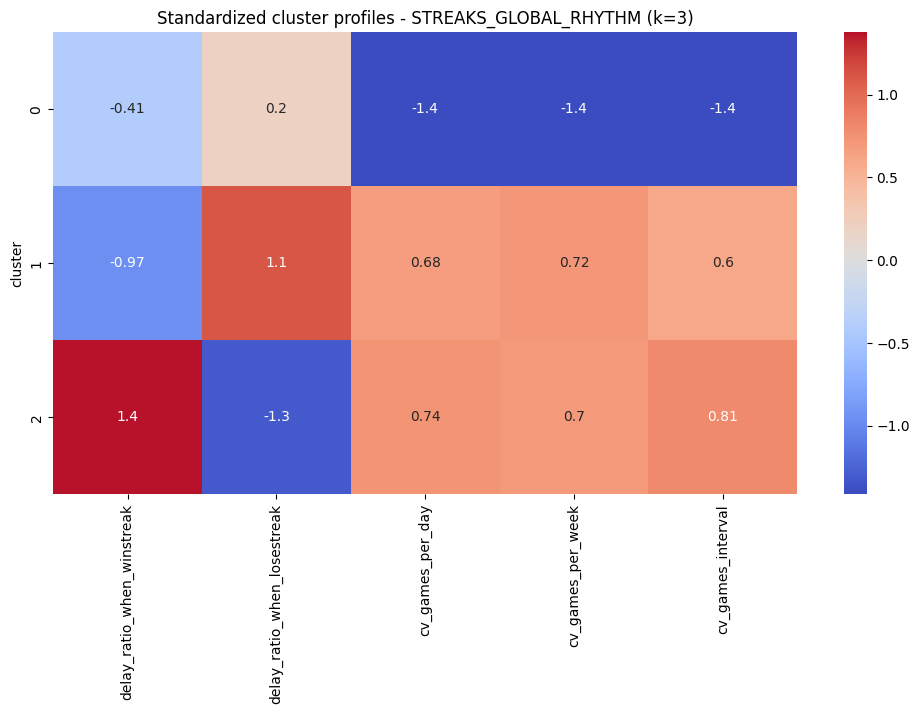

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    analysis["standardized_profiles"],
    annot=True,
    cmap="coolwarm",
    center=0,
)
plt.title(f"Standardized cluster profiles - {feature_set_name} (k={chosen_k})")
plt.show()

### 11.8 Barplot des tailles de cluster

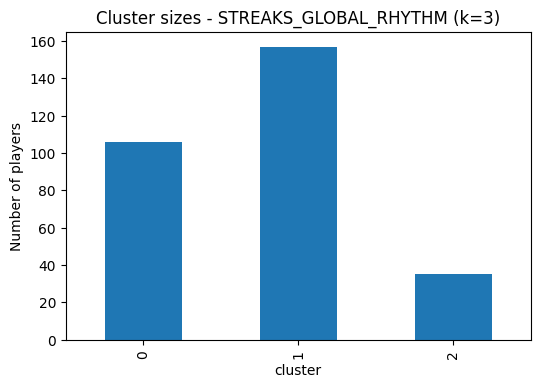

In [ ]:
cluster_sizes = analysis["cluster_sizes"]

plt.figure(figsize=(6, 4))
cluster_sizes.plot(kind="bar")
plt.title(f"Cluster sizes - {feature_set_name} (k={chosen_k})")
plt.ylabel("Number of players")
plt.show()

### 11.9 Barplot des moyennes avec écart-type

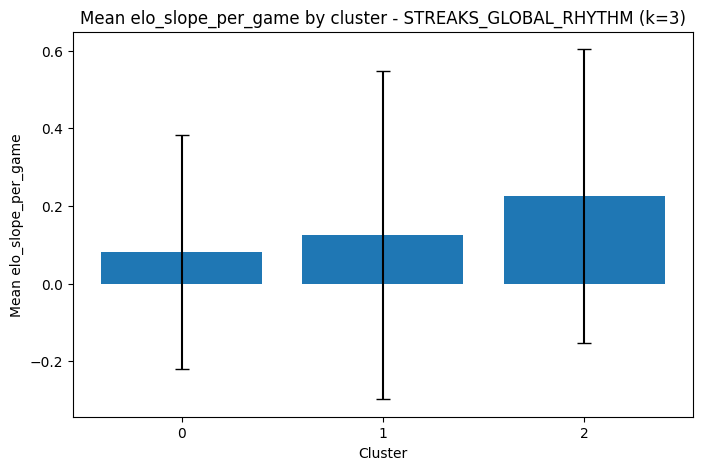

In [ ]:
progression_means = analysis["progression_summary_mean"]["elo_slope_per_game"]
progression_stds = (
    final_dataset_clustered.groupby("cluster")["elo_slope_per_game"].std()
)

plt.figure(figsize=(8, 5))
plt.bar(
    progression_means.index.astype(str),
    progression_means.values,
    yerr=progression_stds.values,
    capsize=5,
)
plt.title(f"Mean elo_slope_per_game by cluster - {feature_set_name} (k={chosen_k})")
plt.xlabel("Cluster")
plt.ylabel("Mean elo_slope_per_game")
plt.show()

### 11.10 Boxplot de elo_slope_per_game par cluster

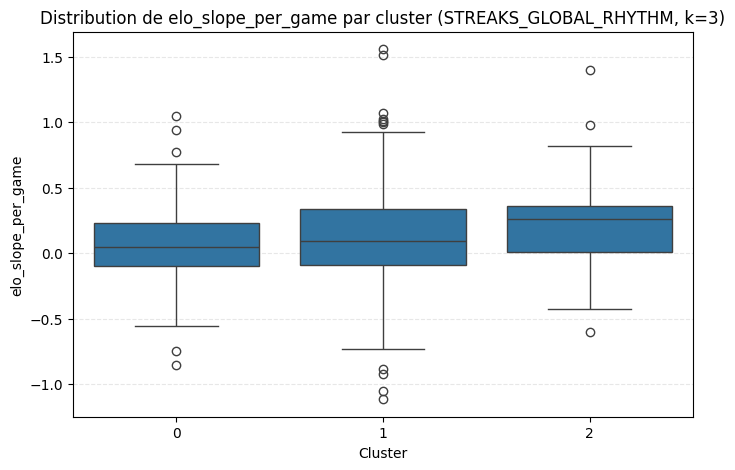

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_dataset_clustered,
    x="cluster",
    y="elo_slope_per_game"
)

plt.title(f"Distribution de elo_slope_per_game par cluster ({feature_set_name}, k={chosen_k})")
plt.xlabel("Cluster")
plt.ylabel("elo_slope_per_game")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

<Axes: xlabel='cluster', ylabel='elo_slope_per_game'>

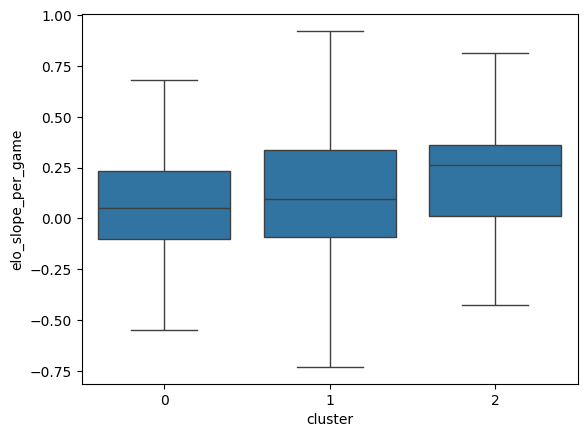

In [ ]:
sns.boxplot(
    data=final_dataset_clustered,
    x="cluster",
    y="elo_slope_per_game",
    showfliers=False  # masque les outliers pour lecture plus claire
)

### 11.11 Table de synthèse

In [ ]:
model_summary = {
    "feature_set_name": feature_set_name,
    "k": chosen_k,
    "best_seed": best_run["seed"],
    "silhouette": best_run["silhouette"],
    "inertia": best_run["inertia"],
    "min_cluster_size": best_run["min_cluster_size"],
    "max_cluster_size": best_run["max_cluster_size"],
    "imbalance_ratio": best_run["imbalance_ratio"],
    "elo_slope_per_game_range": best_run["elo_slope_per_game_range"],
    "elo_slope_per_game_std_between_clusters": best_run["elo_slope_per_game_std_between_clusters"],
    "elo_slope_per_game_std_between_clusters_weighted": best_run["elo_slope_per_game_std_between_clusters_weighted"],
}

model_summary

{'feature_set_name': 'STREAKS_GLOBAL_RHYTHM',
 'k': 3,
 'best_seed': 41,
 'silhouette': 0.23988737774664617,
 'inertia': 608.3311922935272,
 'min_cluster_size': 35,
 'max_cluster_size': 157,
 'imbalance_ratio': 0.2229299363057325,
 'elo_slope_per_game_range': 0.1429078446156132,
 'elo_slope_per_game_std_between_clusters': 0.05980343348077701,
 'elo_slope_per_game_std_between_clusters_weighted': 0.04265680759639635}

## 12. Comparaison inter-modèle

In [ ]:
selected_models = [
    ("TOP6", 4),
    ("TOP6", 5),
    ("TOP10", 5),
    ("TEMPORAL", 5),
]

rows = []

for fs_name, k in selected_models:
    run = get_best_run_for_feature_set(ALL_RESULTS, fs_name, k)
    rows.append({
        "feature_set_name": fs_name,
        "k": k,
        "best_seed": run["seed"],
        "silhouette": run["silhouette"],
        "inertia": run["inertia"],
        "imbalance_ratio": run["imbalance_ratio"],
        "elo_slope_per_game_range": run["elo_slope_per_game_range"],
        "elo_slope_per_game_std_between_clusters": run["elo_slope_per_game_std_between_clusters"],
        "elo_slope_per_game_std_between_clusters_weighted": run["elo_slope_per_game_std_between_clusters_weighted"],
    })

selected_models_df = pd.DataFrame(rows)
selected_models_df

,feature_set_name,k,best_seed,silhouette,inertia,imbalance_ratio,elo_slope_per_game_range,elo_slope_per_game_std_between_clusters,elo_slope_per_game_std_between_clusters_weighted
0,TOP6,4,32,0.188317,713.530248,0.466019,0.133235,0.051972,0.045265
1,TOP6,5,38,0.169510,653.039062,0.409091,0.165922,0.058672,0.050579
2,TOP10,5,27,0.149145,1242.988555,0.326316,0.232415,0.077069,0.063073
3,TEMPORAL,5,14,0.255274,538.557239,0.316327,0.231540,0.085780,0.078704
